In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from plt_overfit import overfit_example, output
from jupyter_utils_common import sigmoid
np.set_printoptions(precision=8)

In [4]:
def compute_cost_linear_reg(x, y, w, b, lambda_ = 1):
    """
    Computes the cost over all examples

    Arguments:
      x (ndarray (m,n): data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar): model parameter
      lambda_ (scalar): controls amount of regularization
    
    Returns:
      total_cost (scalar): cost 
    """

    m = x.shape[0]
    n = len(w)
    cost = 0
    for i in range(m):
        f_wb_i = np.dot(x[i], w) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = cost / (2 * m)

    reg_cost = 0
    for j in range(n):
        reg_cost += (w[j]**2)
    reg_cost = (lambda_ / (2 * m)) * reg_cost

    total_cost = cost + reg_cost
    return total_cost

In [5]:
np.random.seed(1)
x_tmp = np.random.rand(5, 6)
y_tmp = np.array([0, 1, 0, 1, 0])
w_tmp = np.random.rand(x_tmp.shape[1]).reshape(-1) - 0.5
b_tmp = 0.5
lambda_tmp = 0.7
cost_tmp = compute_cost_linear_reg(x_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print("Regularized Cost:", cost_tmp)

Regularized Cost: 0.07917239320214275


In [6]:
def compute_cost_logistic_reg(x, y, w, b, lambda_ = 1):
    """
    Computes the cost over all examples

    Arguments:
      x (ndarray (m,n): data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar): model parameter
      lambda_ (scalar): controls amount of regularization
    
    Returns:
      total_cost (scalar): cost 
    """

    m, n  = x.shape
    cost = 0
    for i in range(m):
        z_i = np.dot(x[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost +=  -y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)

    cost = cost / m

    reg_cost = 0
    for j in range(n):
        reg_cost += (w[j]**2)
    reg_cost = (lambda_ / (2 * m)) * reg_cost

    total_cost = cost + reg_cost
    return total_cost

In [7]:
np.random.seed(1)
x_tmp = np.random.rand(5, 6)
y_tmp = np.array([0, 1, 0, 1, 0])
w_tmp = np.random.rand(x_tmp.shape[1]).reshape(-1) - 0.5
b_tmp = 0.5
lambda_tmp = 0.7
cost_tmp = compute_cost_logistic_reg(x_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print("Regularized Cost:", cost_tmp)

Regularized Cost: 0.6850849138741673


In [8]:
def compute_gradient_linear_reg(x, y, w, b, lambda_): 
    """
    Computes the gradient for linear regression 
    
    Arguments:
      x (ndarray (m,n): data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar): model parameter
      lambda_ (scalar): controls amount of regularization
      
    Returns:
      dj_dw (ndarray (n,)): the gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar): the gradient of the cost w.r.t. the parameter b. 
    """
    m, n = x.shape
    dj_dw = np.zeros((n))
    dj_db = 0

    for i in range(m):                             
        err = (np.dot(x[i], w) + b) - y[i]                 
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * x[i, j]               
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m   
    
    for j in range(n):
        dj_dw[j] = dj_dw[j] + (lambda_ / m) * w[j]

    return dj_db, dj_dw

In [9]:
np.random.seed(1)
x_tmp = np.random.rand(5, 3)
y_tmp = np.array([0, 1, 0, 1, 0])
w_tmp = np.random.rand(x_tmp.shape[1])
b_tmp = 0.5
lambda_tmp = 0.7
dj_db_tmp, dj_dw_tmp =  compute_gradient_linear_reg(x_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print(f"dj_db: {dj_db_tmp}", )
print(f"Regularized dj_dw:\n {dj_dw_tmp.tolist()}", )

dj_db: 0.6648774569425726
Regularized dj_dw:
 [0.29653214748822276, 0.4911679625918033, 0.21645877535865857]


In [12]:
def compute_gradient_logistic_reg(x, y, w, b, lambda_): 
    """
    Computes the gradient for linear regression 
 
    Arguments:
      x (ndarray (m,n): data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar): model parameter
      lambda_ (scalar): controls amount of regularization
    Returns
      dj_dw (ndarray shape (n,)): the gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar): the gradient of the cost w.r.t. the parameter b. 
    """
    m, n = x.shape
    dj_dw = np.zeros((n))  
    dj_db = 0

    for i in range(m):
        f_wb_i = sigmoid(np.dot(x[i], w) + b)
        err_i  = f_wb_i  - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * x[i, j]
        dj_db = dj_db + err_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    for j in range(n):
        dj_dw[j] = dj_dw[j] + (lambda_ / m) * w[j]

    return dj_db, dj_dw


In [13]:
np.random.seed(1)
x_tmp = np.random.rand(5, 3)
y_tmp = np.array([0, 1, 0, 1, 0])
w_tmp = np.random.rand(x_tmp.shape[1])
b_tmp = 0.5
lambda_tmp = 0.7
dj_db_tmp, dj_dw_tmp =  compute_gradient_logistic_reg(x_tmp, y_tmp, w_tmp, b_tmp, lambda_tmp)

print(f"dj_db: {dj_db_tmp}", )
print(f"Regularized dj_dw:\n {dj_dw_tmp.tolist()}", )

dj_db: 0.341798994972791
Regularized dj_dw:
 [0.17380012933994293, 0.32007507881566943, 0.10776313396851499]


Output()

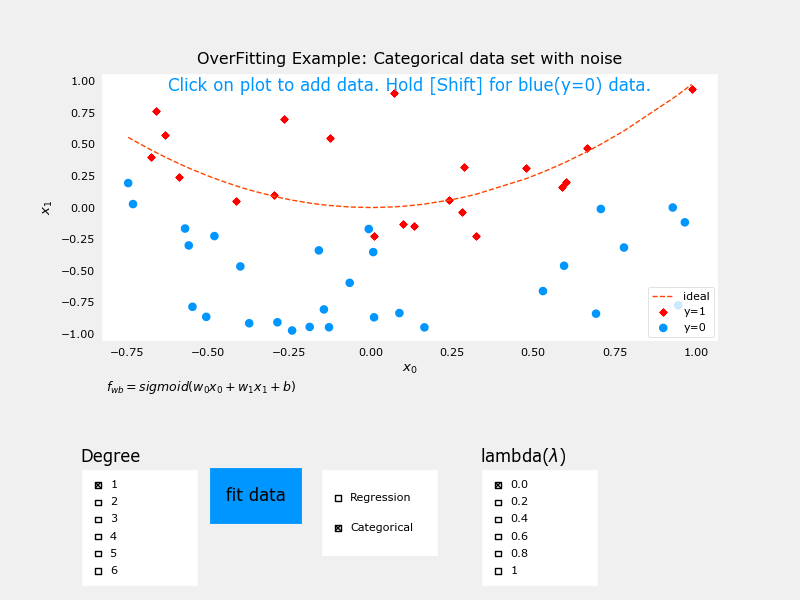

In [14]:
plt.close("all")
display(output)
ofit = overfit_example(True)